## PART A — k-Nearest Neighbors (k-NN)
## Task 1: Dataset Selection (k-NN)

Study Hours & Sleep Hours → Pass / Fail

🔹 Features (X)

Study Hours per day (numeric)
Sleep Hours per day (numeric)

🔹 Label (y)

Pass → 1
Fail → 0

Sample Dataset:
Study Hours	Sleep Hours	Result
2	5	0
3	6	0
4	5	0
5	7	1
6	6	1
7	8	1
8	7	1
3	4	0
6	5	1
4	6	0

## Task 2: Distance Function (From Scratch)

In [1]:
import math

def euclidean_distance(x1, x2):
    """
    Compute the Euclidean distance between two numeric vectors.
    
    Parameters:
    x1, x2 : list or tuple of numbers
        Feature vectors of the same length.
    
    Returns:
    float
        Euclidean distance between x1 and x2
    """
    distance = 0
    for i in range(len(x1)):
        distance += (x1[i] - x2[i])**2
    return math.sqrt(distance)

# Example usage
point1 = [5, 7]  # Study hours, Sleep hours
point2 = [6, 6]
print("Distance:", euclidean_distance(point1, point2))


Distance: 1.4142135623730951


## Task 3: k-NN from Scratch

In [2]:
import math
from collections import Counter

def euclidean_distance(x1, x2):
    """Compute Euclidean distance between two points"""
    distance = 0
    for i in range(len(x1)):
        distance += (x1[i] - x2[i])**2
    return math.sqrt(distance)

class KNN:
    def __init__(self, k=3):
        """
        k: Number of nearest neighbors to consider
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Store the training data.
        
        X: list of feature vectors
        y: list of labels
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        """
        Predict labels for a list of points.
        
        X: list of feature vectors to predict
        Returns: list of predicted labels
        """
        predictions = []
        for x in X:
            # Compute distances to all training points
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
            
            # Get indices of k nearest neighbors
            k_indices = sorted(range(len(distances)), key=lambda i: distances[i])[:self.k]
            
            # Get labels of k nearest neighbors
            k_labels = [self.y_train[i] for i in k_indices]
            
            # Majority vote
            most_common = Counter(k_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return predictions

# ----------------------
# Example Usage
# ----------------------
X_train = [[2,5], [3,6], [4,5], [5,7], [6,6], [7,8], [8,7], [3,4], [6,5], [4,6]]
y_train = [0,0,0,1,1,1,1,0,1,0]

X_test = [[5,6], [3,5]]
knn = KNN(k=3)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
print("Predictions:", predictions)


Predictions: [1, 0]


## Task 4: Effect of k

In [3]:
# Sample Dataset
X_train = [[2,5], [3,6], [4,5], [5,7], [6,6], [7,8], [8,7], [3,4], [6,5], [4,6]]
y_train = [0,0,0,1,1,1,1,0,1,0]

X_test = [[5,6], [3,5], [6,7], [4,4]]
y_test = [1,0,1,0]  # True labels for comparison

# Function to compute accuracy
def accuracy(y_true, y_pred):
    correct = sum(yt == yp for yt, yp in zip(y_true, y_pred))
    return correct / len(y_true)

# Test different k values
for k in [1, 3, 5]:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy(y_test, y_pred)
    print(f"k = {k}: Predictions = {y_pred}, Accuracy = {acc:.2f}")


k = 1: Predictions = [1, 0, 1, 0], Accuracy = 1.00
k = 3: Predictions = [1, 0, 1, 0], Accuracy = 1.00
k = 5: Predictions = [1, 0, 1, 0], Accuracy = 1.00


## Task 5: Visualization (If 2D)

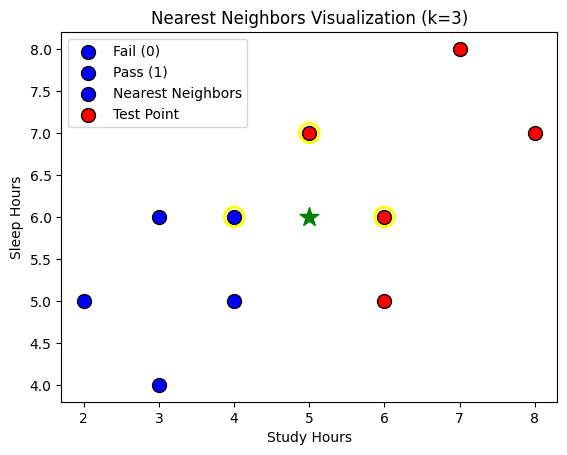

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Sample dataset
X_train = np.array([[2,5], [3,6], [4,5], [5,7], [6,6], [7,8], [8,7], [3,4], [6,5], [4,6]])
y_train = np.array([0,0,0,1,1,1,1,0,1,0])

X_test = np.array([[5,6]])
k = 3

# Fit k-NN
knn = KNN(k=k)
knn.fit(X_train.tolist(), y_train.tolist())

# Compute distances from test point to training points
distances = [euclidean_distance(X_test[0], x) for x in X_train]
k_indices = np.argsort(distances)[:k]

# Plot training points
for i, label in enumerate(y_train):
    color = 'blue' if label==0 else 'red'
    plt.scatter(X_train[i,0], X_train[i,1], c=color, s=100, edgecolors='k')

# Highlight nearest neighbors
for idx in k_indices:
    plt.scatter(X_train[idx,0], X_train[idx,1], facecolors='none', edgecolors='yellow', s=200, linewidths=2)

# Plot test point
plt.scatter(X_test[0,0], X_test[0,1], c='green', marker='*', s=200, label='Test Point')

plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title(f"Nearest Neighbors Visualization (k={k})")
plt.legend(["Fail (0)", "Pass (1)", "Nearest Neighbors", "Test Point"])
plt.show()
